Importing relevant Libraries

**Section 1: Market Overview & Pricing**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

Data loading and exploration

In [3]:
data = pd.read_csv('data/lagos_real_estate_cleaned.csv')
keep_types = [
    'Apartment', 'Terraced', 'Semi Detached', 'Detached', 
    'Maisonette', 'Penthouse', 'Mini Flat', 'Town House', 
    'Mini Duplex', 'Bungalow', 'Triplex'
]
data = data[data['property_type'].isin(keep_types)]
data.head()

,listing_url,title,location,property_type,beds,baths,status,post-date-absolute,price(millions_NGN),log_price_millions_NGN,...,Private Elevator,Study,Cinema,Garden,Water Front,Private Cinema,Water View,Football Pitch,Tennis Court,Sauna
0,https://cwlagos.com/property/3-bedroom-apartme...,3 Bedroom Apartment + BQ,Banana Island,Apartment,3.0,3.0,Rent,2025-06-21,30.000,3.401197,...,1,0,1,0,0,0,0,0,0,0
1,https://cwlagos.com/property/terrace-for-sale-...,TERRACE IN BANANA ISLAND IKOYI,Banana Island,Terraced,5.0,5.0,Sale,2025-06-21,3616.925,8.193379,...,0,0,0,0,0,0,0,0,0,0
4,https://cwlagos.com/property/brand-new-5-bedro...,Brand New 5 Bedroom Semi-Detached House with W...,Banana Island,Semi Detached,5.0,5.0,Sale,2024-11-18,2170.155,7.682554,...,1,0,0,0,1,0,1,0,0,0
5,https://cwlagos.com/property/six-bedroom-fully...,Six Bedroom Fully Detached house in Banana Island,Banana Island,Detached,0.0,0.0,Sale,2025-06-21,5200.000,8.556414,...,0,0,1,0,0,0,0,0,0,0
9,https://cwlagos.com/property/6-bedroom-detache...,6-Bedroom Detached House in Banana Island,Banana Island,Detached,6.0,6.0,Sale,2025-09-19,7233.850,8.886527,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data.to_csv('data/lagos_real_estate_cleaned_final.csv')

In [5]:
data.shape

(847, 42)

In [6]:
data.describe()

,beds,baths,price(millions_NGN),log_price_millions_NGN,24hrs Power,30kva generator,5kva inverter,Balcony,BQ,Car Park,...,Private Elevator,Study,Cinema,Garden,Water Front,Private Cinema,Water View,Football Pitch,Tennis Court,Sauna
count,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,...,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000,847.000000
mean,3.519481,3.521842,438.431682,4.730439,0.354191,0.343566,0.344746,0.354191,0.207792,0.371901,...,0.139315,0.116883,0.110980,0.060213,0.021251,0.108619,0.023613,0.004723,0.008264,0.002361
std,2.052338,2.052314,1221.776836,1.817346,0.478550,0.475179,0.475566,0.478550,0.405967,0.483598,...,0.346480,0.321471,0.314293,0.238021,0.144307,0.311344,0.151929,0.068599,0.090586,0.048564
min,0.000000,0.000000,0.030000,-3.506558,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.000000,30.000000,3.401197,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,4.000000,125.000000,4.828314,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,4.000000,450.000000,6.109248,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,47.000000,47.000000,28935.400000,10.272821,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Question 1 - \
What does the overall price distribution of Lagos housing listings look like?**

Data Visualization

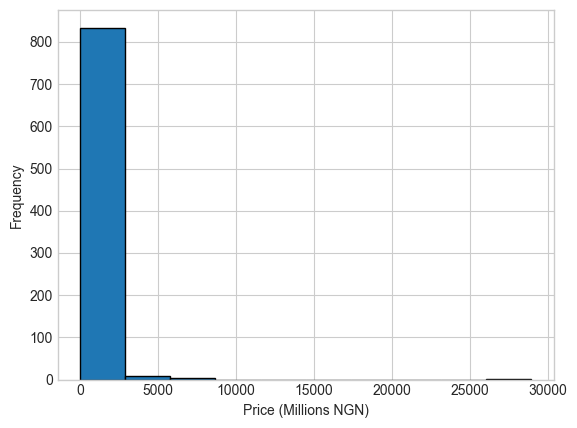

In [7]:
plt.hist(data['price(millions_NGN)'], edgecolor='black')
plt.xlabel('Price (Millions NGN)')
plt.ylabel('Frequency')
plt.show()

As shown by the figure above, our data is highly right-skewed and cannot be easily represented using the raw price values. Instead we would use the log of the price values to better visualize our data.

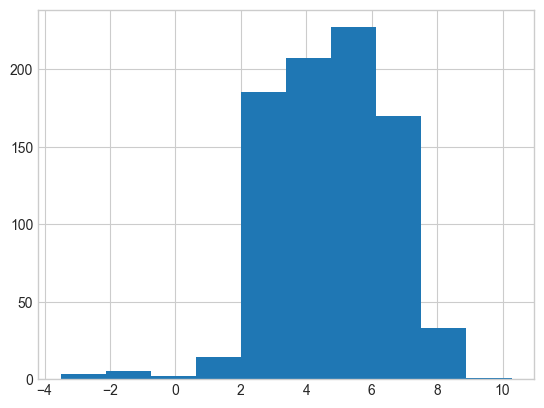

In [8]:
plt.hist(data['log_price_millions_NGN']);

Using the log prices gives a better visualization and reveals an approximate normal/bell-shaped distribution, but the distribution of the data is still not represented properly. 

Using the seaborn library and KDE we can get a much better visualization of our data and it's underlying distribution pattern more clearly as shown below.

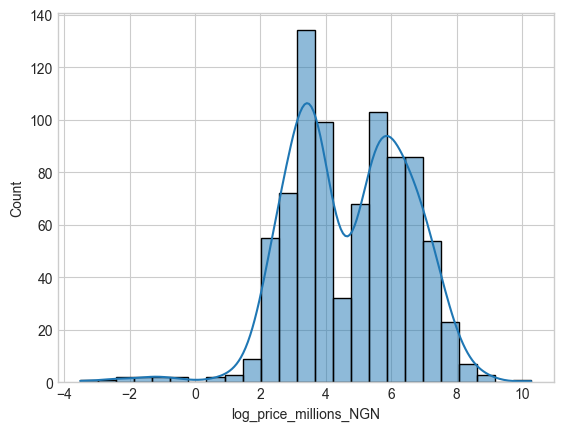

In [9]:
import seaborn as sns
sns.histplot(data=data, x='log_price_millions_NGN', kde=True)
plt.show()

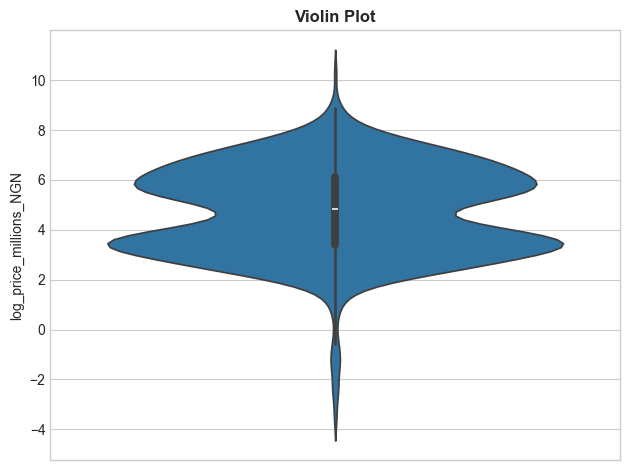

In [21]:
sns.violinplot(data=data, y='log_price_millions_NGN') 
plt.title('Violin Plot', fontsize=12, fontweight='bold') 
plt.tight_layout() 
plt.show()

**In summary - \
The overall price distribution of Lagos housing listings is right-skewed when viewed in raw prices, but becomes approximately normal when using log-transformed prices. Most properties are concentrated in the lower-to-middle price range with a small number of high-end luxury properties. The visualizations collectively show this is not a uniform distribution but rather has a clear central tendency with defined spread.**

\
**Question 2 - \
What is the typical (median) price range for properties in Lagos?**

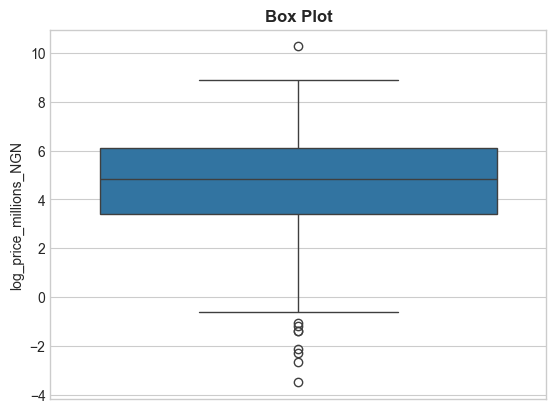

In [ ]:
# Box plot
ax = sns.boxplot(data=data, y='log_price_millions_NGN')
ax.set_title('Box Plot', fontsize=12, fontweight='bold');

The horizontal line inside the box represents the median (50th percentile) of the data. This points to the median log value of **4.828**. Converting back from the natural logarithm; \
The typical median price for properties in Lagos is : **125.0 million NGN**

\
**Question 3 -\
How are listings distributed across low-, mid-, and high-price segments?**

Once again, referring back to the Box plot (for data visualization), listings can be distibuted across low, mid and high price segments using the the Box-plot quartiles. \
Low-priced segments corresponds to price listings less than or equal to Q1,\
Mid-priced segments corresponds to price listings between Q1 and Q3, while\
High-priced segments corresponds to price listings above Q3.

In [19]:
df = data.copy()
q1 = df['price(millions_NGN)'].quantile(0.25)
q3 = df['price(millions_NGN)'].quantile(0.75)

low = df[df['price(millions_NGN)'] <= q1]
mid = df[(df['price(millions_NGN)'] > q1) & (df['price(millions_NGN)'] < q3)]
high = df[df['price(millions_NGN)'] >= q3]

print(f'Number of houses in the Low-priced segment : {len(low)}')
print(f'Number of houses in the Mid-priced segment : {len(mid)}')
print(f'Number of houses in the High-priced segment : {len(high)}')

print(f'\nLower Quartile of the price data: {q1} millions_NGN')
print(f'Median of the price data: {df["price(millions_NGN)"].median()} millions_NGN')
print(f'Upper quartile of the price data: {q3} millions_NGN')

Number of houses in the Low-priced segment : 246
Number of houses in the Mid-priced segment : 373
Number of houses in the High-priced segment : 228

Lower Quartile of the price data: 30.0 millions_NGN
Median of the price data: 125.0 millions_NGN
Upper quartile of the price data: 450.0 millions_NGN


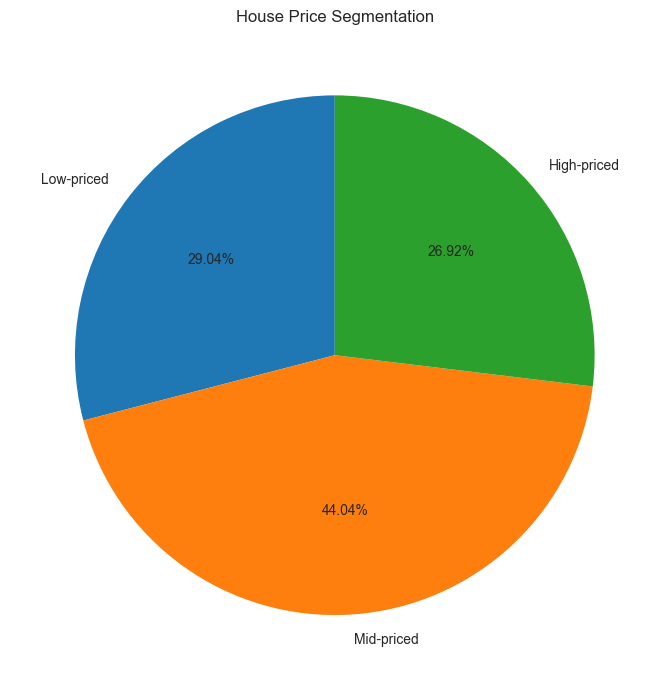

In [18]:
import matplotlib.pyplot as plt

# Values (counts)
sizes = [len(low), len(mid), len(high)]
labels = ['Low-priced', 'Mid-priced', 'High-priced']

plt.figure(figsize=(7, 7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90
)

plt.title('House Price Segmentation')
plt.tight_layout()
plt.show()

**In conclusion - \
Prices below or equal to 20 million_NGN are in the low price segments\
Prices between 20 million and 482.5 million_NGN are in the mid price segment\
Prices above or equals to 482.5 million_NGN are in the high price segment.**

**Question 4 -\
How does price vary with number of bedrooms?**

Grouping the price data by the number of beds using various summary statistics, we can further have an understanding of our data, and how the prices of houses vary with number of bedrooms.

In [20]:
df_plot = df.dropna(subset=['beds','price(millions_NGN)']).copy()
# Ensuring integer bedroom counts:
try:
    df_plot['beds'] = df_plot['beds'].astype(int)
except Exception:
    df_plot['beds'] = df_plot['beds'].round().astype(int)

# Showing group statistics:
grp = df_plot.groupby('beds')['price(millions_NGN)'].agg(['count','median','mean']).reset_index()
print(grp.to_string(index=False))

 beds  count     median        mean
    0     18   62.50000  482.297222
    1     41   18.00000   88.779700
    2    150   40.00000  138.692521
    3    193   36.16925  203.231678
    4    253  195.00000  396.724020
    5    164  500.00000  750.835201
    6     22 1300.00000 2912.258591
    7      1   50.00000   50.000000
    9      2 1337.44315 1337.443150
   11      1 2400.00000 2400.000000
   14      1 1300.00000 1300.000000
   47      1 5000.00000 5000.000000


To show spread and outliers in our data, we would be making use of a Box plot.

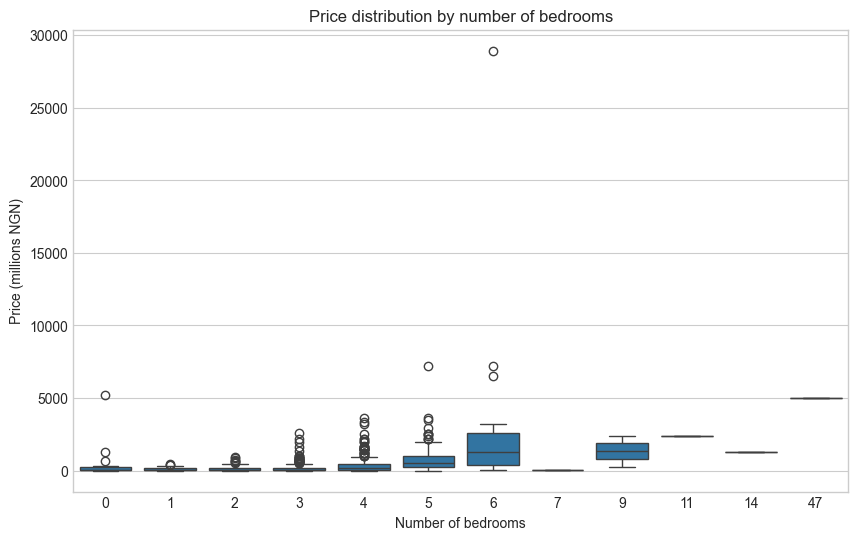

In [16]:
# boxplot: price distribution by beds
plt.figure(figsize=(10,6))
sns.boxplot(data=df_plot, x='beds', y='price(millions_NGN)')
plt.xlabel('Number of bedrooms')
plt.ylabel('Price (millions NGN)')
plt.title('Price distribution by number of bedrooms')
plt.show()

Lastly, to answer the question itself, we would be making a plot of the median price per bedrooms, as shown below:

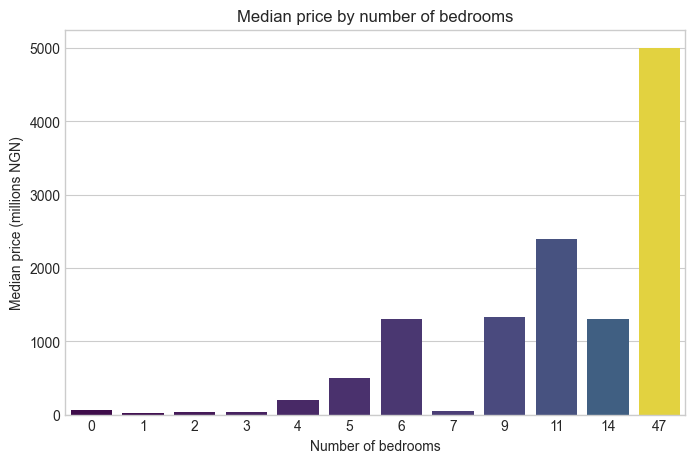

In [17]:
# median bar chart
medians = df_plot.groupby('beds')['price(millions_NGN)'].median().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(x=medians.index, y=medians.values, palette='viridis', hue=medians.index, legend=False)
plt.xlabel('Number of bedrooms')
plt.ylabel('Median price (millions NGN)')
plt.title('Median price by number of bedrooms')
plt.show()

**In conclusion: \
Median price generally increases with number of bedrooms, but distributions overlap and outliers (very expensive properties) cause large variability (as we can see in the Box plot).**